In [15]:
import warnings
warnings.filterwarnings('ignore')

In [16]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

In [17]:
def mean_relative_error(y_true, y_pred):
    """
    Calcula el error relativo medio en porcentaje.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask   = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def calculate_r2(y_true, y_pred):
    """
    Calcula el coeficiente de determinación R² usando la fórmula:
    R² = 1 - (Σ(y_true - y_pred)²) / (Σ(y_true - mean(y_true))²)
    """
    import numpy as np
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return (1 -  ss_res/ss_tot) if ss_res != 0 else 1.0

In [18]:
def plot_comparison_by_rep(merged_df, vitruve_col, video_col, title=""):
    """
    Crea un gráfico donde el eje x es la repetición y el eje y muestra los valores de la métrica.
    Se grafican dos series (Vitruve y Video) con líneas y marcadores. También incluye
    líneas de tendencia (regresión lineal) para cada serie.
    """
    rep = merged_df['repetition_index'].astype(int).values
    vitruve_y = merged_df[vitruve_col].astype(str).str.replace(',', '.').astype(float).values
    video_y   = merged_df[video_col].astype(str).str.replace(',', '.').astype(float).values

    plt.figure(figsize=(8,6))
    
    # Graficamos los datos en forma de línea con marcadores
    plt.plot(rep, vitruve_y, marker='o', color='blue', label='Vitruve', alpha=0.7)
    plt.plot(rep, video_y,   marker='s', color='red',  label='Video', alpha=0.7)
    
    # Agregamos líneas de tendencia (regresión lineal) para cada serie
    if len(rep) >= 2:
        # Tendencia para Vitruve
        m_v, b_v = np.polyfit(rep, vitruve_y, 1)
        rep_line = np.linspace(rep.min(), rep.max(), 100)
        vitruve_line = m_v * rep_line + b_v
        plt.plot(rep_line, vitruve_line, linestyle='--', color='blue',
                 label=f"Vitruve fit: y={m_v:.2f}x+{b_v:.2f}")
        
        # Tendencia para Video
        m_vid, b_vid = np.polyfit(rep, video_y, 1)
        video_line = m_vid * rep_line + b_vid
        plt.plot(rep_line, video_line, linestyle='--', color='red',
                 label=f"Video fit: y={m_vid:.2f}x+{b_vid:.2f}")

    plt.xlabel("Repetición")
    plt.ylabel("Valor de la métrica")
    plt.title(title or f"Comparación por repetición: {vitruve_col} vs {video_col}")
    plt.legend()
    plt.grid(True)
    plt.show()

In [19]:
vitruve_columns = ['Workout Date', '# Set', '# Rep.', 'Type*', 'VMP (m/s)', 'Peak Velocity (m/s)', 'ROM (cm)']
video_columns = ['repetition', 'rep_time','ROM (cm)', 'VMED (m/s)', 'VMAX (m/s)']

In [20]:
metrics = [
    ('Vitruve_VMED', 'Video_VMED'),
    ('Vitruve_VMAX', 'Video_VMAX'),
    ('Vitruve_ROM',  'Video_ROM')]
df_video_deadlift_lat = pd.read_csv('data_export/deadlift/20250414_053112_deadlift_metrics.csv')
df_video_deadlift_lat['repetition_index'] = range(1, len(df_video_deadlift_lat) + 1)
print(f"the reps count measured in video is: {df_video_deadlift_lat.shape[0]}")

df_vitruve = pd.read_csv('data/TEST_10-04-2025.csv', skiprows=1, index_col=False)
df_deadlift_vitruve_lat =  df_vitruve[df_vitruve['# Set'].isin([33,34])][df_vitruve['Type*']=='C']
df_deadlift_vitruve_lat['repetition_index'] = range(1, len(df_deadlift_vitruve_lat) + 1)
print(f"the reps count measured in vitruve is: {df_deadlift_vitruve_lat.shape[0]}")


df_deadlift_vitruve_lat.rename(columns={
    'MPV (m/s)': 'Vitruve_VMED',
    'Peak Velocity (m/s)': 'Vitruve_VMAX',
    'ROM (cm)': 'Vitruve_ROM'
}, inplace=True)
df_video_deadlift_lat.rename(columns={
    'VMED (m/s)': 'Video_VMED',
    'VMAX (m/s)': 'Video_VMAX',
    'ROM (cm)': 'Video_ROM'
}, inplace=True)


df_deadlift_lat = pd.merge(df_deadlift_vitruve_lat, df_video_deadlift_lat, how = 'inner', on = 'repetition_index')

the reps count measured in video is: 100
the reps count measured in vitruve is: 100


*** Comparando Vitruve_VMED vs Video_VMED ***
 MSE: 0.0511
 MAE: 0.2150
 MRE: 21.55%

 R²: -14.6186

*** Comparando Vitruve_VMAX vs Video_VMAX ***
 MSE: 0.0198
 MAE: 0.1041
 MRE: 7.32%

 R²: -1.8914

*** Comparando Vitruve_ROM vs Video_ROM ***
 MSE: 21.8989
 MAE: 3.1407
 MRE: 7.74%

 R²: 0.5082



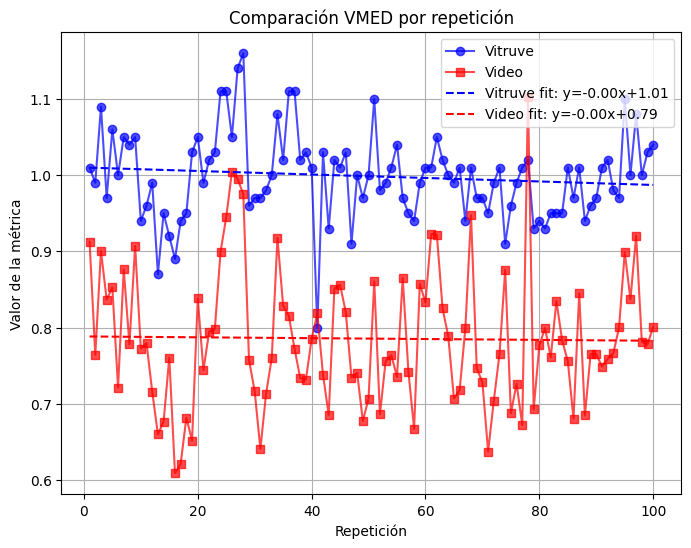

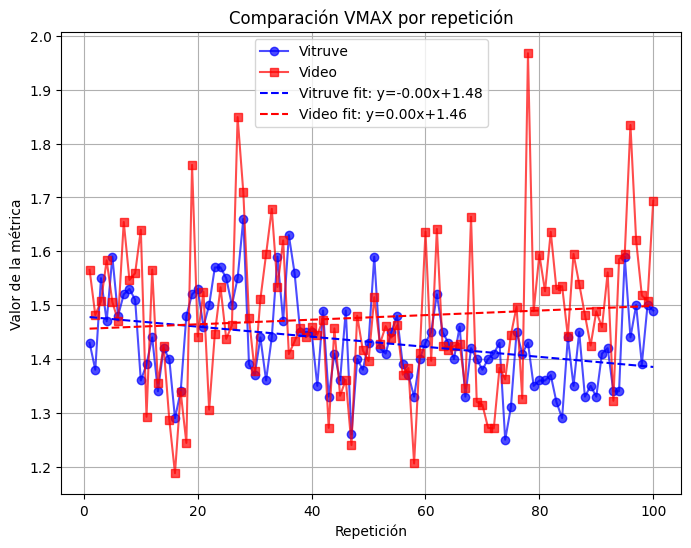

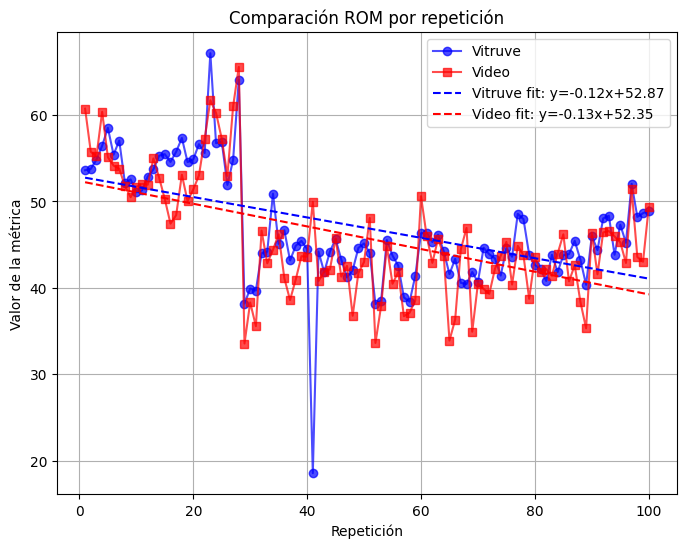

Ratio VMED (Vitruve/Video) = 1.2711062838351692
Ratio VMAX (Vitruve/Video) = 0.9689254146733415
Ratio ROM (Vitruve/Video) = 1.0257011367896245


In [21]:
for vitruve_col, video_col in metrics:
    # Extraemos las series
    y_true = df_deadlift_lat[vitruve_col].astype(str).str.replace(',', '.').astype(float)
    y_pred = df_deadlift_lat[video_col].astype(str).str.replace(',', '.').astype(float)
    
    # Calculamos MSE y MAE
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mre = mean_relative_error(y_true, y_pred)
    r2 = calculate_r2(y_true, y_pred)

    print(f"*** Comparando {vitruve_col} vs {video_col} ***")
    print(f" MSE: {mse:.4f}")
    print(f" MAE: {mae:.4f}")
    print(f" MRE: {mre:.2f}%\n")
    print(f" R²: {r2:.4f}\n")

plot_comparison_by_rep(df_deadlift_lat, 'Vitruve_VMED', 'Video_VMED', "Comparación VMED por repetición")
plot_comparison_by_rep(df_deadlift_lat, 'Vitruve_VMAX', 'Video_VMAX', "Comparación VMAX por repetición")
plot_comparison_by_rep(df_deadlift_lat, 'Vitruve_ROM',  'Video_ROM',  "Comparación ROM por repetición")


df_vmed = df_deadlift_lat[['Vitruve_VMED','Video_VMED']].dropna()
vitruve_mean_vmed = df_vmed['Vitruve_VMED'].astype(str).str.replace(',', '.').astype(float).mean()
video_mean_vmed   = df_vmed['Video_VMED'].astype(str).str.replace(',', '.').astype(float).mean()

ratio_vmed = vitruve_mean_vmed / video_mean_vmed
print("Ratio VMED (Vitruve/Video) =", ratio_vmed)

df_vmax = df_deadlift_lat[['Vitruve_VMAX','Video_VMAX']].dropna()
vitruve_mean_vmax = (df_vmax['Vitruve_VMAX'].astype(str)
                                       .str.replace(',', '.')
                                       .astype(float)
                                       .mean())
video_mean_vmax   = (df_vmax['Video_VMAX'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
ratio_vmax = vitruve_mean_vmax / video_mean_vmax
print("Ratio VMAX (Vitruve/Video) =", ratio_vmax)

df_rom = df_deadlift_lat[['Vitruve_ROM','Video_ROM']].dropna()
vitruve_mean_rom = (df_rom['Vitruve_ROM'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
video_mean_rom   = (df_rom['Video_ROM'].astype(str)
                                   .str.replace(',', '.')
                                   .astype(float)
                                   .mean())
ratio_rom = vitruve_mean_rom / video_mean_rom
print("Ratio ROM (Vitruve/Video) =", ratio_rom)